In [1]:
import pandas as pd 
from pgmpy.models import DiscreteBayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt
import mlflow
import pickle
from pgmpy.estimators import MaximumLikelihoodEstimator

In [2]:
graph = DiscreteBayesianNetwork(
    [('Compute_Overload','CPU_Usage'),
    ('Compute_Overload','API_Latency'),
    ('Memory_Leak','RAM_Usage'),
    ('Memory_Leak','API_Latency'),
    ('Network_Partition','API_Latency'),
    ('Network_Partition','Error_Rate'),
    ('App_Crash','Error_Rate')],
)

In [3]:
graph.to_graphviz().draw("graph.png",prog="dot")

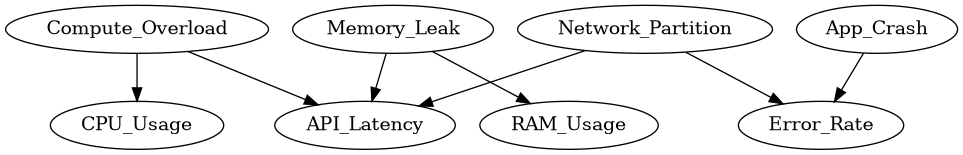

In [4]:
from IPython.display import Image
Image(filename='graph.png') 

In [5]:
df = pd.read_csv('simulated_server_telemetry.csv')

In [6]:
categorical_cols = ['CPU_Usage', 'RAM_Usage', 'API_Latency', 'Error_Rate']

# 2. Convert them to the 'category' type
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [7]:
df['Compute_Overload'] = (df['Root_Cause'] == 'Compute_Overload').astype(int)
df['Memory_Leak']      = (df['Root_Cause'] == 'Memory_Leak').astype(int)
df['Network_Partition']= (df['Root_Cause'] == 'Network_Partition').astype(int)
df['App_Crash']        = (df['Root_Cause'] == 'App_Crash').astype(int)
df = df.drop(columns=['Root_Cause'])
df

,CPU_Usage,RAM_Usage,API_Latency,Error_Rate,Compute_Overload,Memory_Leak,Network_Partition,App_Crash
0,Normal,Normal,Normal,Zero,0,0,0,0
1,Normal,Normal,Normal,Zero,0,0,0,0
2,Normal,Normal,Normal,Spiking,0,0,0,1
3,Normal,Normal,Normal,Zero,0,0,0,0
4,Normal,Normal,Normal,Zero,0,0,0,0
...,...,...,...,...,...,...,...,...
4995,Normal,Normal,Timeout,Spiking,0,0,1,0
4996,Normal,Normal,Normal,Zero,0,0,0,0
4997,Normal,Normal,Normal,Zero,0,0,0,0
4998,Normal,Normal,Normal,Zero,0,0,0,0


In [8]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [9]:
mlflow.set_experiment("Server_Fault_Diagnosis")

2026/03/19 17:47:11 INFO mlflow.tracking.fluent: Experiment with name 'Server_Fault_Diagnosis' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1773922631021, experiment_id='1', last_update_time=1773922631021, lifecycle_stage='active', name='Server_Fault_Diagnosis', tags={}, workspace='default'>

In [10]:
with mlflow.start_run() as run:
    
    # TRAIN THE MODEL: This calculates all the CPTs instantly
    graph.fit(df, estimator=MaximumLikelihoodEstimator)
    
    # Log metadata for your team / evaluators
    mlflow.log_param("dataset_size", len(df))
    mlflow.log_param("estimator", "MaximumLikelihoodEstimator")
    mlflow.log_param("nodes", len(graph.nodes()))
    mlflow.log_param("edges", len(graph.edges()))
    
    # Verify the model compiled correctly (no cycles, CPTs sum to 1)
    assert graph.check_model()
    print("Model validation passed! CPTs are mathematically sound.")
    
    # 5. Save the trained model to your hard drive
    model_path = "bayesian_fault_model.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(graph, f)
        
    # 6. Upload the file to MLflow's artifact registry
    mlflow.log_artifact(model_path)
    
    print(f"Success! Run ID: {run.info.run_id}")
    print("Model saved to MLflow.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CPU_Usage': 'C', 'RAM_Usage': 'C', 'API_Latency': 'C', 'Error_Rate': 'C', 'Compute_Overload': 'N', 'Memory_Leak': 'N', 'Network_Partition': 'N', 'App_Crash': 'N'}


Model validation passed! CPTs are mathematically sound.
Success! Run ID: a66542578be140fd8640ae4a348d5b60
Model saved to MLflow.
🏃 View run popular-shark-47 at: http://127.0.0.1:5000/#/experiments/1/runs/a66542578be140fd8640ae4a348d5b60
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [12]:
for cpd in graph.get_cpds():
    print(cpd)


+---------------------+-------+
| Compute_Overload(0) | 0.891 |
+---------------------+-------+
| Compute_Overload(1) | 0.109 |
+---------------------+-------+
+---------------------+---------------------+---------------------+
| Compute_Overload    | Compute_Overload(0) | Compute_Overload(1) |
+---------------------+---------------------+---------------------+
| CPU_Usage(Critical) | 0.0                 | 0.726605504587156   |
+---------------------+---------------------+---------------------+
| CPU_Usage(High)     | 0.0345679012345679  | 0.27339449541284405 |
+---------------------+---------------------+---------------------+
| CPU_Usage(Normal)   | 0.9654320987654321  | 0.0                 |
+---------------------+---------------------+---------------------+
+-----------------------+-----+----------------------+
| Compute_Overload      | ... | Compute_Overload(1)  |
+-----------------------+-----+----------------------+
| Memory_Leak           | ... | Memory_Leak(1)       |
+-------

In [13]:
from sklearn.metrics import accuracy_score
import mlflow

# 1. Separate the "Symptoms" (Input) from the "Causes" (Ground Truth)
symptoms_df = df[['CPU_Usage', 'RAM_Usage', 'API_Latency', 'Error_Rate']]
ground_truth = df[['Compute_Overload', 'Memory_Leak', 'Network_Partition', 'App_Crash']]

print("Running inference on 5000 rows to test accuracy. This might take a minute...")

# 2. Ask the model to predict the causes based only on the symptoms
predictions = graph.predict(symptoms_df)

# 3. Calculate Accuracy for each fault type
metrics = {}
for col in ground_truth.columns:
    acc = accuracy_score(ground_truth[col], predictions[col])
    metrics[f"accuracy_{col}"] = acc
    print(f"Accuracy for {col}: {acc * 100:.2f}%")

# 4. Log these metrics to your existing MLflow run
# (Make sure to use the run_id from your previous success message)
# Alternatively, wrap this in a new mlflow.start_run() block
with mlflow.start_run(run_name="Evaluation_Run"):
    mlflow.log_metrics(metrics)
    print("Metrics logged to MLflow!")

Running inference on 5000 rows to test accuracy. This might take a minute...


/home/master-shreyash/Documents/PGM-fault-diagnosis-system/venv/lib/python3.12/site-packages/pgmpy/models/DiscreteBayesianNetwork.py:720: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(
/home/master-shreyash/Documents/PGM-fault-diagnosis-system/venv/lib/python3.12/site-packages/pgmpy/models/DiscreteBayesianNetwork.py:720: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply

  0%|          | 0/18 [00:00<?, ?it/s]

Accuracy for Compute_Overload: 99.88%
Accuracy for Memory_Leak: 99.80%
Accuracy for Network_Partition: 100.00%
Accuracy for App_Crash: 100.00%
Metrics logged to MLflow!
🏃 View run Evaluation_Run at: http://127.0.0.1:5000/#/experiments/1/runs/ec935ef5a5e34bae994fb64ac3d31739
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
